# テーマ6 CNNによる画像分類

## 目的
- 画像分類でCNNがどのように使われるかを体験する
- 画像がピクセルの集合であり、縦横の空間構造を持つことを確認する
- Digits dataset を用いて学習と予測を行う
- 正解例・誤分類画像を見て、モデルの限界を考える

## 注意
- このテンプレートは PyTorch を使います
- 環境に PyTorch がない場合は、教員側で事前セットアップが必要です


## CNNが画像に向いている理由

画像は、縦横に並んだピクセルの集合です。表形式データのように列を独立に見るだけでなく、近くのピクセル同士の関係が重要になります。

CNN は、画像の小さな領域にフィルタを当てて特徴を取り出します。畳み込みのイメージは次の式で表せます。

$$
S(i, j) = \sum_m \sum_n I(i+m, j+n)K(m,n)
$$

ここで、$I$ は画像、$K$ はフィルタ、$S$ は取り出された特徴です。フィルタは、線、角、濃淡の変化などを検出する役割を持ちます。


### 表形式データとの違い

テーマ5のニューラルネットワークでは、特徴量を横に並べた表形式データを入力しました。CNN では、画像の縦・横の位置関係を残したまま入力します。

例えば、同じ黒いピクセルでも、左上にあるのか中央にあるのかで意味が変わります。CNN は小さな範囲を少しずつ見ながら、線や角のような局所的な特徴を拾うため、画像分類に向いています。


### Step 0: ライブラリを読み込む
PyTorch と補助ライブラリを読み込み、CNN 学習の準備をします。ここでデバイス確認も行います。

### Step 0: CNN 学習の流れを確認する
このノートブックでは、手書き数字データを使って PyTorch で CNN を学習します。通常の表形式データと違い、画像では近くのピクセルどうしの関係に注目する点を意識してください。


In [1]:
# ===== Step 0: ライブラリ読み込み =====
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans']

torch.manual_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device =', device)

device = cpu


### Step 1: 画像データを読み込む
Digits データセットを読み込み、画像の形とラベルの形を確認します。最初の画像を表示して、入力のイメージをつかみます。

#### 解説: 画像データの形

Digits データセットの画像は 8×8 ピクセルです。PyTorch の CNN に入力するため、形を次のように整えます。

$$
(データ数, チャンネル数, 高さ, 幅)
$$

白黒画像なのでチャンネル数は 1 です。カラー画像なら、通常は RGB の3チャンネルになります。


画像データの形 = (1797, 8, 8)
ラベルの形 = (1797,)


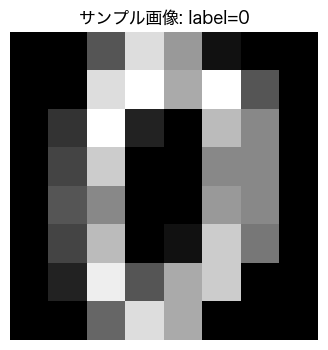

In [2]:
# ===== Step 1: データ読み込み =====
# TODO: Digits dataset を読み込む
digits = load_digits()
images = digits.images / 16.0  # 画素値を 0 から 1 にそろえる
labels = digits.target

print('画像データの形 =', images.shape)
print('ラベルの形 =', labels.shape)

plt.figure(figsize=(4, 4))
plt.imshow(images[0], cmap='gray')
plt.title(f'サンプル画像: label={labels[0]}')
plt.axis('off')
plt.show()

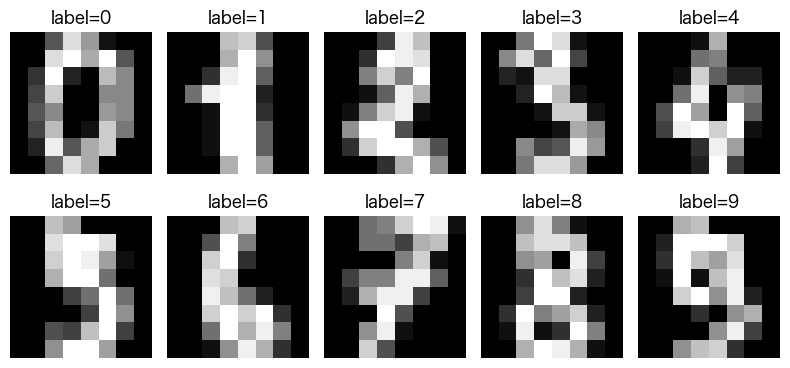

In [3]:
# ===== 追加演習: 複数の数字を並べて見る =====
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for ax, image, label in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'label={label}')
    ax.axis('off')
plt.tight_layout()
plt.show()


### Step 2: 学習用データを作る
画像データを train と test に分けて、PyTorch の Tensor と DataLoader に変換します。CNN に渡せる形へ整える工程です。

In [4]:
# ===== Step 2: 学習用データ作成 =====
# TODO: train と test に分け、PyTorch 用 Tensor に変換する
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

print('train batch 数 =', len(train_loader))

train batch 数 = 23


### Step 3: CNN モデルを定義する
畳み込み、ReLU、プーリング、全結合層を組み合わせた簡単な CNN を定義します。画像の一部分に注目して特徴を取り出す流れを確認してください。


#### 解説: プーリング

`MaxPool2d(2)` は、2×2 の範囲から最大値を取り出して画像を小さくします。これにより、位置が少しずれても似た特徴として扱いやすくなり、計算量も減ります。

このモデルでは、8×8 の画像が畳み込みとプーリングを通って、最後に分類用の全結合層へ渡されます。


In [5]:
# ===== Step 3: CNNモデル =====
# TODO: CNN の構造を読んで、入力と出力の形を確認する
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 2 * 2, 32),
            nn.ReLU(),
            nn.Linear(32, 10),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=32, bias=True)
    (2): ReLU()
    (3): Linear(in_features=32, out_features=10, bias=True)
  )
)


### Step 4: モデルを学習する
定義した CNN を学習ループに通して、訓練を進めます。epoch ごとの loss を見て、学習が安定しているか確認します。

In [6]:
# ===== Step 4: 学習 =====
# TODO: epoch 数を変えて結果を比較してもよい
epochs = 8

epoch_losses = []
epoch_accs = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch_images, batch_labels in train_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == batch_labels).sum().item()
        total += batch_labels.size(0)

    train_acc = correct / total
    epoch_losses.append(total_loss / len(train_loader))
    epoch_accs.append(train_acc)
    print(f'Epoch {epoch + 1}/{epochs}, loss={total_loss / len(train_loader):.4f}, acc={train_acc:.3f}')

Epoch 1/8, loss=2.1749, acc=0.257
Epoch 2/8, loss=1.0603, acc=0.669
Epoch 3/8, loss=0.4834, acc=0.843
Epoch 4/8, loss=0.3504, acc=0.880
Epoch 5/8, loss=0.2203, acc=0.931
Epoch 6/8, loss=0.1819, acc=0.941
Epoch 7/8, loss=0.1739, acc=0.937
Epoch 8/8, loss=0.1699, acc=0.932


### Step 4.1: 学習曲線を確認する
学習が進むにつれて loss が下がっていく様子、そして学習精度が上がっていく様子を確認します。loss が下がらない場合は過学習や学習率の問題を、accuracy が上がらない場合は未学習を考えます。

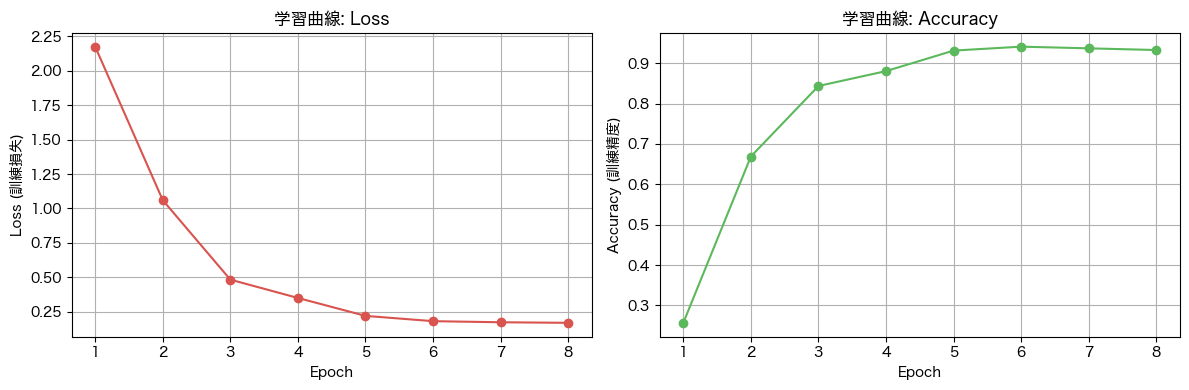

In [7]:
# ===== Step 4.1: 学習曲線の描画 =====
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, epochs + 1), epoch_losses, 'o-', color='#D9534F')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (訓練損失)')
axes[0].set_title('学習曲線: Loss')
axes[0].grid(True)

axes[1].plot(range(1, epochs + 1), epoch_accs, 'o-', color='#5CB85C')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (訓練精度)')
axes[1].set_title('学習曲線: Accuracy')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Accuracy: 0.931
誤分類数 = 25


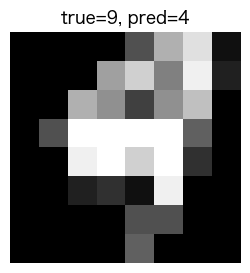

In [8]:
# ===== Step 5: 評価と誤分類の可視化 =====
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        outputs = model(batch_images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch_labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
accuracy = (all_preds == all_labels).mean()
print(f'Accuracy: {accuracy:.3f}')

wrong_index = np.where(all_preds != all_labels)[0]
print('誤分類数 =', len(wrong_index))

if len(wrong_index) > 0:
    idx = wrong_index[0]  # TODO: 別の誤分類例も見てみる
    plt.figure(figsize=(3, 3))
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'true={all_labels[idx]}, pred={all_preds[idx]}')
    plt.axis('off')
    plt.show()

#### 追加観察: 正解例と誤分類例を比べる

誤分類画像だけを見るのではなく、正しく分類できた画像とも比べてください。

- 線が薄い、太い、途切れている
- 他の数字と形が似ている
- 書き方に個人差がある
- 8×8 なので細かい情報が失われている

モデルの限界は、データの難しさとセットで考えると説明しやすくなります。


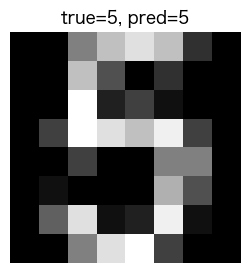

In [9]:
# ===== 追加演習: 正解例を1つ表示する =====
correct_index = np.where(all_preds == all_labels)[0]
if len(correct_index) > 0:
    idx = correct_index[0]
    plt.figure(figsize=(3, 3))
    plt.imshow(X_test[idx], cmap='gray')
    plt.title(f'true={all_labels[idx]}, pred={all_preds[idx]}')
    plt.axis('off')
    plt.show()


### Step 6: 学習結果を確認した後に考えること
Accuracy だけでなく、正しく分類できた画像と間違えた画像の違いを見ます。誤分類例は、モデルが苦手なケースを考える手がかりになります。


## 振り返り
- CNN が画像分類に使われる理由を、自分の言葉で説明してください。
- 誤分類画像を見ると、なぜ間違えたと思いますか。
- テーマ5のニューラルネットワークと比べて、CNN では何が画像向けになっていると感じましたか。


## 演習課題

以下の演習をノートブック上で実行し、結果を確認してください。

### 演習1: CNNモデルの学習 (簡単)

1. テンプレートのコードに従って、手書き数字データでCNNを学習させてください。
2. 訓練データとテストデータの accuracy を確認してください。
3. 誤分類された画像を5つ表示し、なぜ間違えたのか考えてください。

```python
# ここにコードを書いてください
# テンプレートのモデル定義・学習コードを実行

# 誤分類例を確認（PyTorch 版）
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor.to(device))
    preds = test_outputs.argmax(dim=1).cpu().numpy()

wrong_idx = np.where(preds != y_test)[0]

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, idx in zip(axes, wrong_idx[:5]):
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True: {y_test[idx]}, Pred: {preds[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()
```

### 演習2: フィルタ数の影響 (簡単)

1. CNNのフィルタ数を 16, 32, 64 と変えて学習させ、accuracy を比較してください。
2. フィルタ数が増えると、学習時間と精度はどのように変わりましたか。

```python
# ここにコードを書いてください
filter_sizes = [16, 32, 64]

for n_filters in filter_sizes:
    # CNNモデルのフィルタ数を変えて学習
    # ...（テンプレートのコードを参照）
    print(f"Filters={n_filters}: test_acc={test_acc:.3f}")
```

---

## レポート課題

以下のレポートを提出してください（A4 1ページ程度、またはノートブックのセルに記述）。

### レポート項目

1. **CNNとは** (200字程度)
   - CNNが通常のニューラルネットワークとどのように違うか、自分の言葉で説明してください。また、なぜ画像分類に適しているのでしょうか。

2. **畳み込みとプーリング** (200字程度)
   - 畳み込み（コンボリューション）とプーリングがそれぞれ何をしているかを説明してください。数式ではなく、直感的な説明で構いません。

3. **誤分類の考察** (300字程度)
   - 演習で確認した誤分類例のうち、印象に残ったものを1つ選び、なぜ間違えたのか考えてください。数字の形が曖昧だった、書き方が特殊だったなど、具体的な理由を記述してください。

4. **CNNの限界** (200字程度)
   - CNNは画像分類に強力ですが、どのような場合に失敗しやすいですか。また、精度をさらに高める方法として何が考えられますか。

